<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/MODELOS_COM_OU_SEM_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [2]:
#load the data
from google.colab import files
uploaded=files.upload()

Saving 01-04T184148_000_mode1.csv to 01-04T184148_000_mode1.csv


In [3]:
df = pd.read_csv("01-04T184148_000_mode1.csv")

print("Dimensões da base de dados:", df.shape)
print("\nAmostra dos dados:\n", df.head())


Dimensões da base de dados: (2048, 9)

Amostra dos dados:
    timestamp  pCut::Motor_Torque  pCut::CTRL_Position_controller::Lag_error  \
0      0.008            0.199603                                   0.027420   
1      0.012            0.281624                                   0.002502   
2      0.016            0.349315                                  -0.018085   
3      0.020            0.444450                                  -0.054680   
4      0.024            0.480923                                  -0.042770   

   pCut::CTRL_Position_controller::Actual_position  \
0                                        628392628   
1                                        628392625   
2                                        628392621   
3                                        628392617   
4                                        628392613   

   pCut::CTRL_Position_controller::Actual_speed  \
0                                   -920.104980   
1                                   -93

In [4]:
# Separação de variáveis independentes e dependente
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

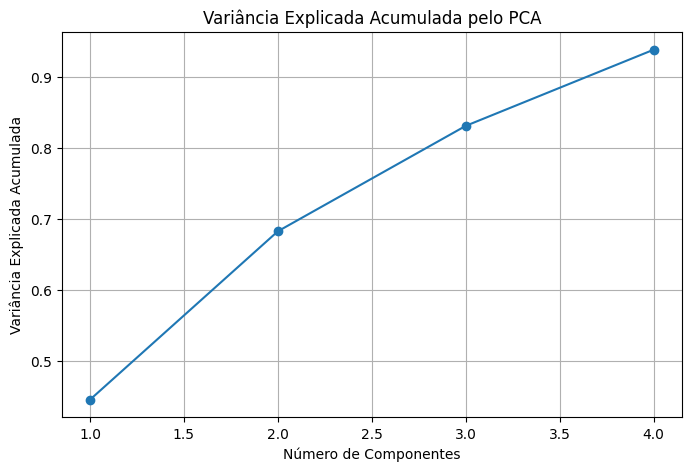

In [6]:
# Ajuste do PCA e cálculo da variância explicada
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Variância explicada por cada componente
var_explicada = pca.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(var_explicada)+1), var_acumulada, marker='o')
plt.title("Variância Explicada Acumulada pelo PCA")
plt.xlabel("Número de Componentes")
plt.ylabel("Variância Explicada Acumulada")
plt.grid(True)
plt.show()

In [8]:
modelos = {
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, random_state=42)
}

In [11]:
def avaliar_modelo(modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    return r2, rmse, mae

In [12]:
#AVALIAÇÃO DOS MODELOS COM E SEM PCA
resultados = []

for nome, modelo in modelos.items():
    # Modelo com dados originais
    r2, rmse, mae = avaliar_modelo(modelo, X_train, X_test, y_train, y_test)
    resultados.append([nome, "Sem PCA", r2, rmse, mae])

    # Modelo com dados transformados pelo PCA (2 componentes)
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    r2_pca, rmse_pca, mae_pca = avaliar_modelo(modelo, X_train_pca, X_test_pca, y_train, y_test)
    resultados.append([nome, "Com PCA (2)", r2_pca, rmse_pca, mae_pca])

# Conversão em DataFrame
resultados_df = pd.DataFrame(resultados, columns=["Modelo", "PCA", "R²", "RMSE", "MAE"])
print("\nResultados Comparativos:\n", resultados_df)


Resultados Comparativos:
           Modelo          PCA        R²       RMSE        MAE
0          Lasso      Sem PCA  0.648276  42.291786  34.750366
1          Lasso  Com PCA (2)  0.564862  47.040159  41.326027
2          Ridge      Sem PCA  0.624917  43.673589  37.472301
3          Ridge  Com PCA (2)  0.564860  47.040260  41.325398
4  Random Forest      Sem PCA  0.999983   0.295338   0.035249
5  Random Forest  Com PCA (2)  0.978323  10.499210   1.336044
6        XGBoost      Sem PCA  0.999608   1.411213   0.181991
7        XGBoost  Com PCA (2)  0.979081  10.314010   1.171522


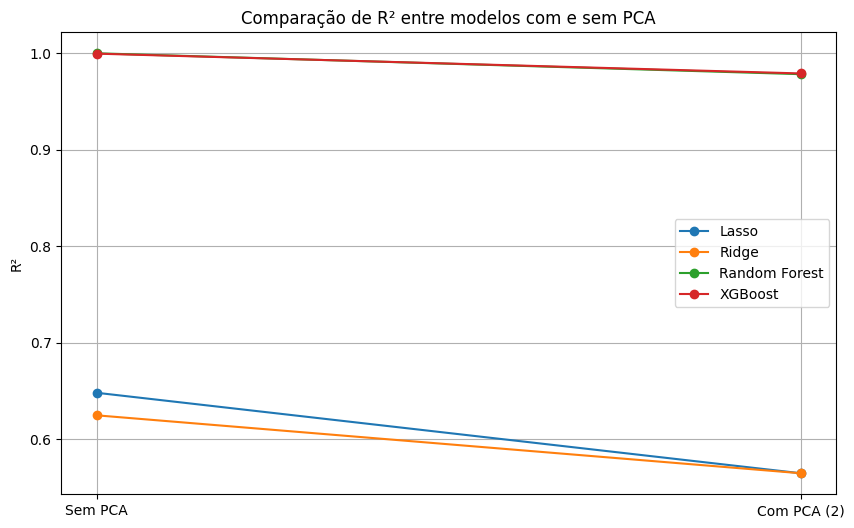

In [13]:
#VISUALIZAÇÃO DOS RESULTADOS
fig, ax = plt.subplots(figsize=(10,6))
for modelo in resultados_df["Modelo"].unique():
    subset = resultados_df[resultados_df["Modelo"] == modelo]
    ax.plot(subset["PCA"], subset["R²"], marker='o', label=modelo)
ax.set_title("Comparação de R² entre modelos com e sem PCA")
ax.set_ylabel("R²")
ax.legend()
plt.grid(True)
plt.show()
